# Load groundwork 

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


import scanpy as sc

import os

import scvi

import seaborn as sns


def order_m(m):
    n = min(*m.shape)
    
    ordered_cols = []
    remain_cols = list(range(m.shape[1]))
    
    for i in range(n):
        ic = m[i, remain_cols].argmax()
        c = remain_cols[ic]
        ordered_cols.append(c)
        remain_cols.remove(c)
    
    return ordered_cols, remain_cols




canonical_markers = ["IL32", "LTB", "CD3D",
    "IL7R", "LDHB", "FCGR3A", 
    "CD68", "MS4A1", "GNLY", 
    "CD3E", "CD14", "CD14", 
    "FCGR3A", "LYZ", "PPBP", 
    "CD8A", "PPBP", "CST3", 
    "NKG7", "MS4A7", "MS4A1", 
    "CD8A", "CD4", "NCAM1"]

    

In [3]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'

h5_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2-outs-raw_feature_bc_matrix-matrix.h5ad')

barcodes_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.barcodes.tsv')

features_file = os.path.join(data_dir, 'GSM7102997_VIB_10xmultiome_2.features.tsv')

h5 = sc.read_h5ad(h5_file)

features_pd = pd.read_csv(features_file, header=None, sep='\t')

barcodes_pd = pd.read_csv(barcodes_file, header=None, sep='\t')

## It's feature -by- barcode matrix, need to transpose
h5.var = barcodes_pd
h5.obs = features_pd 
h5.obs.columns = ['feature_id', 'name', 'feature_type', 'chrom', 'start', 'end']
h5.var.columns = ['barcodes']


## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000_test_norm'
entropy_downstream_dir = os.path.join(entropy_dir, 'DownstreamReanalysis')
entropy_peak_file = os.path.join(entropy_downstream_dir, 'entropy_peakvi.h5ad')
peak_file = os.path.join(entropy_downstream_dir, 'standard_peakvi.h5ad')

entropy_peak = sc.read_h5ad(entropy_peak_file)
peak = sc.read_h5ad(peak_file)

# Rename peakvi clustering columns
entropy_peak.obs['clusters_peakvi_entropy'] = entropy_peak.obs['clusters_peakvi']
peak.obs['clusters_peakvi_standard'] = peak.obs['clusters_peakvi']

# Load entropy score and add to entropy_peak obs
entropy_score_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')
entropy_score_pd = pd.read_csv(entropy_score_file, sep=',', index_col=0)
entropy_peak.obs = entropy_peak.obs.merge(entropy_score_pd[['Entropy', 'Entropy_open_region']], left_on='barcodes', right_index=True, how='left')

# atac clsutering at higher resolutions (than previously used)
atac_resolution = 0.5
sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)
sc.tl.leiden(peak, key_added='clusters_peakvi_highres_standard', resolution=atac_resolution)


# atac-rna-barcode map 
bc_map_file = '/home/syyang/adipose_ln/multiom/atac_rna_barcodes_map.tsv'
bc_map_pd = pd.read_csv(bc_map_file, sep='\t')




## load peakvi models for DARS analysis 
standard_peak_model_dir = os.path.join(entropy_downstream_dir, 'standard_peak_peakvi_model')
entropy_peak_model_dir =os.path.join(entropy_downstream_dir, 'entropy_peak_peakvi_model')
standard_peak_model =scvi.model.PEAKVI.load(standard_peak_model_dir, adata=peak)
entropy_peak_model =scvi.model.PEAKVI.load(entropy_peak_model_dir, adata=entropy_peak)


# Summary statistics about Fraction of Reads in Peaks (FRIP)
standard_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_peaks.csv')
entropy_peak_frip_file = os.path.join(entropy_dir, 'fragments_overlap_peaks', 'summary_statistics_frag_overlap_entropypeaks.csv')


standard_peak_frip = pd.read_csv(standard_peak_frip_file, index_col=None, sep='\t')
entropy_peak_frip = pd.read_csv(entropy_peak_frip_file, index_col=None, sep='\t')
standard_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip.rename(columns={'1': 'barcode'}, inplace=True)
entropy_peak_frip['atac_bc'] = entropy_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip['atac_bc'] = standard_peak_frip['barcode'].str.split('-1').str[0]
standard_peak_frip.set_index('atac_bc', inplace=True)
entropy_peak_frip.set_index('atac_bc', inplace=True)

/tmp/ipykernel_52891/2704537721.py:43: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(entropy_peak, key_added='clusters_peakvi_highres_entropy', resolution=atac_resolution)


INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000_test_norm/DownstreamReanalysis/standard_peak_pe
         akvi_model/model.pt already downloaded                                                                    


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

INFO     File                                                                                                      
         /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000_test_norm/DownstreamReanalysis/entropy_peak_pea
         kvi_model/model.pt already downloaded                                                                     


/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_

In [4]:
entropy_peak, peak, h5, features_pd.shape, barcodes_pd.shape, bc_map_pd.shape

(AnnData object with n_obs × n_vars = 2126 × 36730
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_entropy', 'Entropy', 'Entropy_open_region', 'clusters_peakvi_highres_entropy'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap', 'clusters_peakvi_highres_entropy'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 2126 × 31116
     obs: 'barcodes', '_scvi_batch', '_scvi_labels', 'clusters_peakvi', 'clusters_peakvi_standard', 'clusters_peakvi_highres_standard'
     var: 'peak'
     uns: '_scvi_manager_uuid', '_scvi_uuid', 'clusters_peakvi', 'neighbors', 'umap', 'clusters_peakvi_highres_standard'
     obsm: 'X_peakvi', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 104068 × 687495
     obs: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end'
     var: 'barcodes',
 (104068, 6),
 (687495, 1

# Plot atac re-clustering with higher resolution

## Matching atac bc with RNA bc

In [5]:
bc_map = bc_map_pd.set_index('atac_barcodes')

entropy_peak.obs['atac_bc'] =  entropy_peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
entropy_peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in entropy_peak.obs.columns:
    entropy_peak.obs = entropy_peak.obs.join(bc_map, how='inner')


peak.obs['atac_bc'] =  peak.obs['barcodes'].map(lambda x: x.split('-1')[0])
peak.obs.set_index('atac_bc', inplace=True)
if 'rna_barcodes' not in peak.obs.columns:
    peak.obs = peak.obs.join(bc_map, how='inner')


bc_passed_entropy_df = entropy_peak.obs[['rna_barcodes']]

# RNA clustering

In [6]:
# prepare for rna-bc correspondence to atac entropy filtered barcodes
entropy_passed_bc_map=bc_passed_entropy_df.reset_index(inplace=False)
entropy_passed_bc_map.set_index('rna_barcodes', inplace=True)
entropy_passed_bc_map.columns = ['atac_bc']


h5_rna_ = h5.transpose()
h5_rna_.obs['rna_barcodes'] = h5_rna_.obs['barcodes'].map(lambda x: x.split('-1')[0])
h5_rna_.obs.set_index('rna_barcodes', inplace=True)


# select gene expression only, and only the barcodes that passed entropy filtering
h5_rna_ = h5_rna_[:, h5_rna_.var['feature_type'] == 'Gene Expression']
h5_rna_ = h5_rna_[h5_rna_.obs.index.isin(entropy_passed_bc_map.index), :]
h5_rna_.obs = h5_rna_.obs.join(entropy_passed_bc_map, how='inner')

# calculate total RNA QC metrics
h5_rna_.obs['total_RNA_UMI'] = h5_rna_.X.sum(axis=1)
h5_rna_.obs['total_RNA_UMI_log'] = np.log1p(h5_rna_.obs['total_RNA_UMI'])
h5_rna_.obs['n_genes_by_RNA_counts'] = (h5_rna_.X > 0).sum(axis=1)
h5_rna_.obs['N_MT_counts'] = h5_rna_.X[:, h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].sum(axis=1)
h5_rna_.obs['MT%'] = h5_rna_.obs['N_MT_counts'] / h5_rna_.obs['total_RNA_UMI'] * 100

X_10k = sc.pp.normalize_total(h5_rna_, target_sum=1e4, inplace=False)['X']
h5_rna_.layers['log1p_counts'] = np.log1p(X_10k.copy())

h5_rna = h5_rna_[:, ~h5_rna_.var.name.apply(lambda x: x.startswith('MT-'))].copy() # Remove MT genes

# Add gene_name column 
h5_rna.var['gene_name'] = h5_rna.var['name'].astype(str)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [7]:
h5_rna, h5_rna_.shape

(AnnData object with n_obs × n_vars = 2126 × 36588
     obs: 'barcodes', 'atac_bc', 'total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%'
     var: 'feature_id', 'name', 'feature_type', 'chrom', 'start', 'end', 'gene_name'
     layers: 'log1p_counts',
 (2126, 36601))

In [8]:
sc.pp.filter_genes(h5_rna, min_counts=3)
h5_rna.raw = h5_rna # keep full dimension safe
h5_rna.layers['counts'] = h5_rna.X
sc.pp.highly_variable_genes(
h5_rna,
flavor="seurat_v3",
n_top_genes=4000,
layer="counts",
subset=False)

In [10]:
# scvi.settings.seed = 0
# scvi.model.SCVI.setup_anndata(h5_rna, layer="counts")
# vae = scvi.model.SCVI(h5_rna, n_layers=3, n_latent=30, gene_likelihood="nb")
# vae.train()
# h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()

# sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
# sc.tl.umap(h5_rna, min_dist=0.3)

# print("Save integrated samples into .h5ad file and trained SCVI model into subfolder\n") 
# vae_model_folder=os.path.join(entropy_dir, "_RNA_scvi_model")
# vae.save(vae_model_folder)
vae_model_folder=os.path.join(entropy_dir, "_RNA_scvi_model")
vae =scvi.model.SCVI.load(vae_model_folder, adata=h5_rna)
h5_rna.obsm["RNA_scVI"] = vae.get_latent_representation()
sc.pp.neighbors(h5_rna, use_rep='RNA_scVI')
sc.tl.umap(h5_rna, min_dist=0.3)


Seed set to 0
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/scvi/model/_scvi.py:168: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 

Epoch 400/400: 100%|██████████| 400/400 [01:35<00:00,  4.56it/s, v_num=1, train_loss_step=5.14e+3, train_loss_epoch=5.21e+3]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [01:35<00:00,  4.19it/s, v_num=1, train_loss_step=5.14e+3, train_loss_epoch=5.21e+3]
Save integrated samples into .h5ad file and trained SCVI model into subfolder



ValueError: /mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000_test_norm/_RNA_scvi_model already exists. Please provide another directory for saving.

In [11]:
# clustering using scVI latent representation via Leiden
sc.tl.leiden(h5_rna, key_added="leiden_RNA_scVI", resolution=atac_resolution + 0.1)

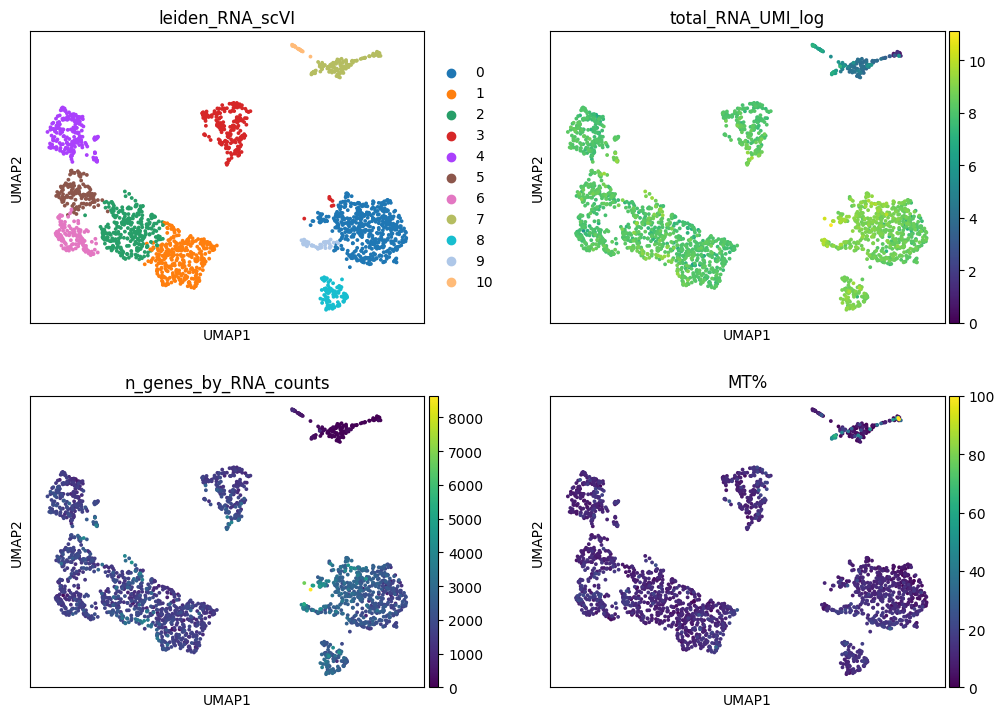

In [12]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'MT%'], wspace=0.2, size=30, ncols=2)

In [13]:
# See concordance between two clustering results between Standard peak clustering and Entropy filtered peak clustering
entropy_peak_df = entropy_peak.obs.copy()
entropy_peak_df.set_index('barcodes', inplace=True)

peak_df = peak.obs.copy()
peak_df.set_index('barcodes', inplace=True)

## Marker genes

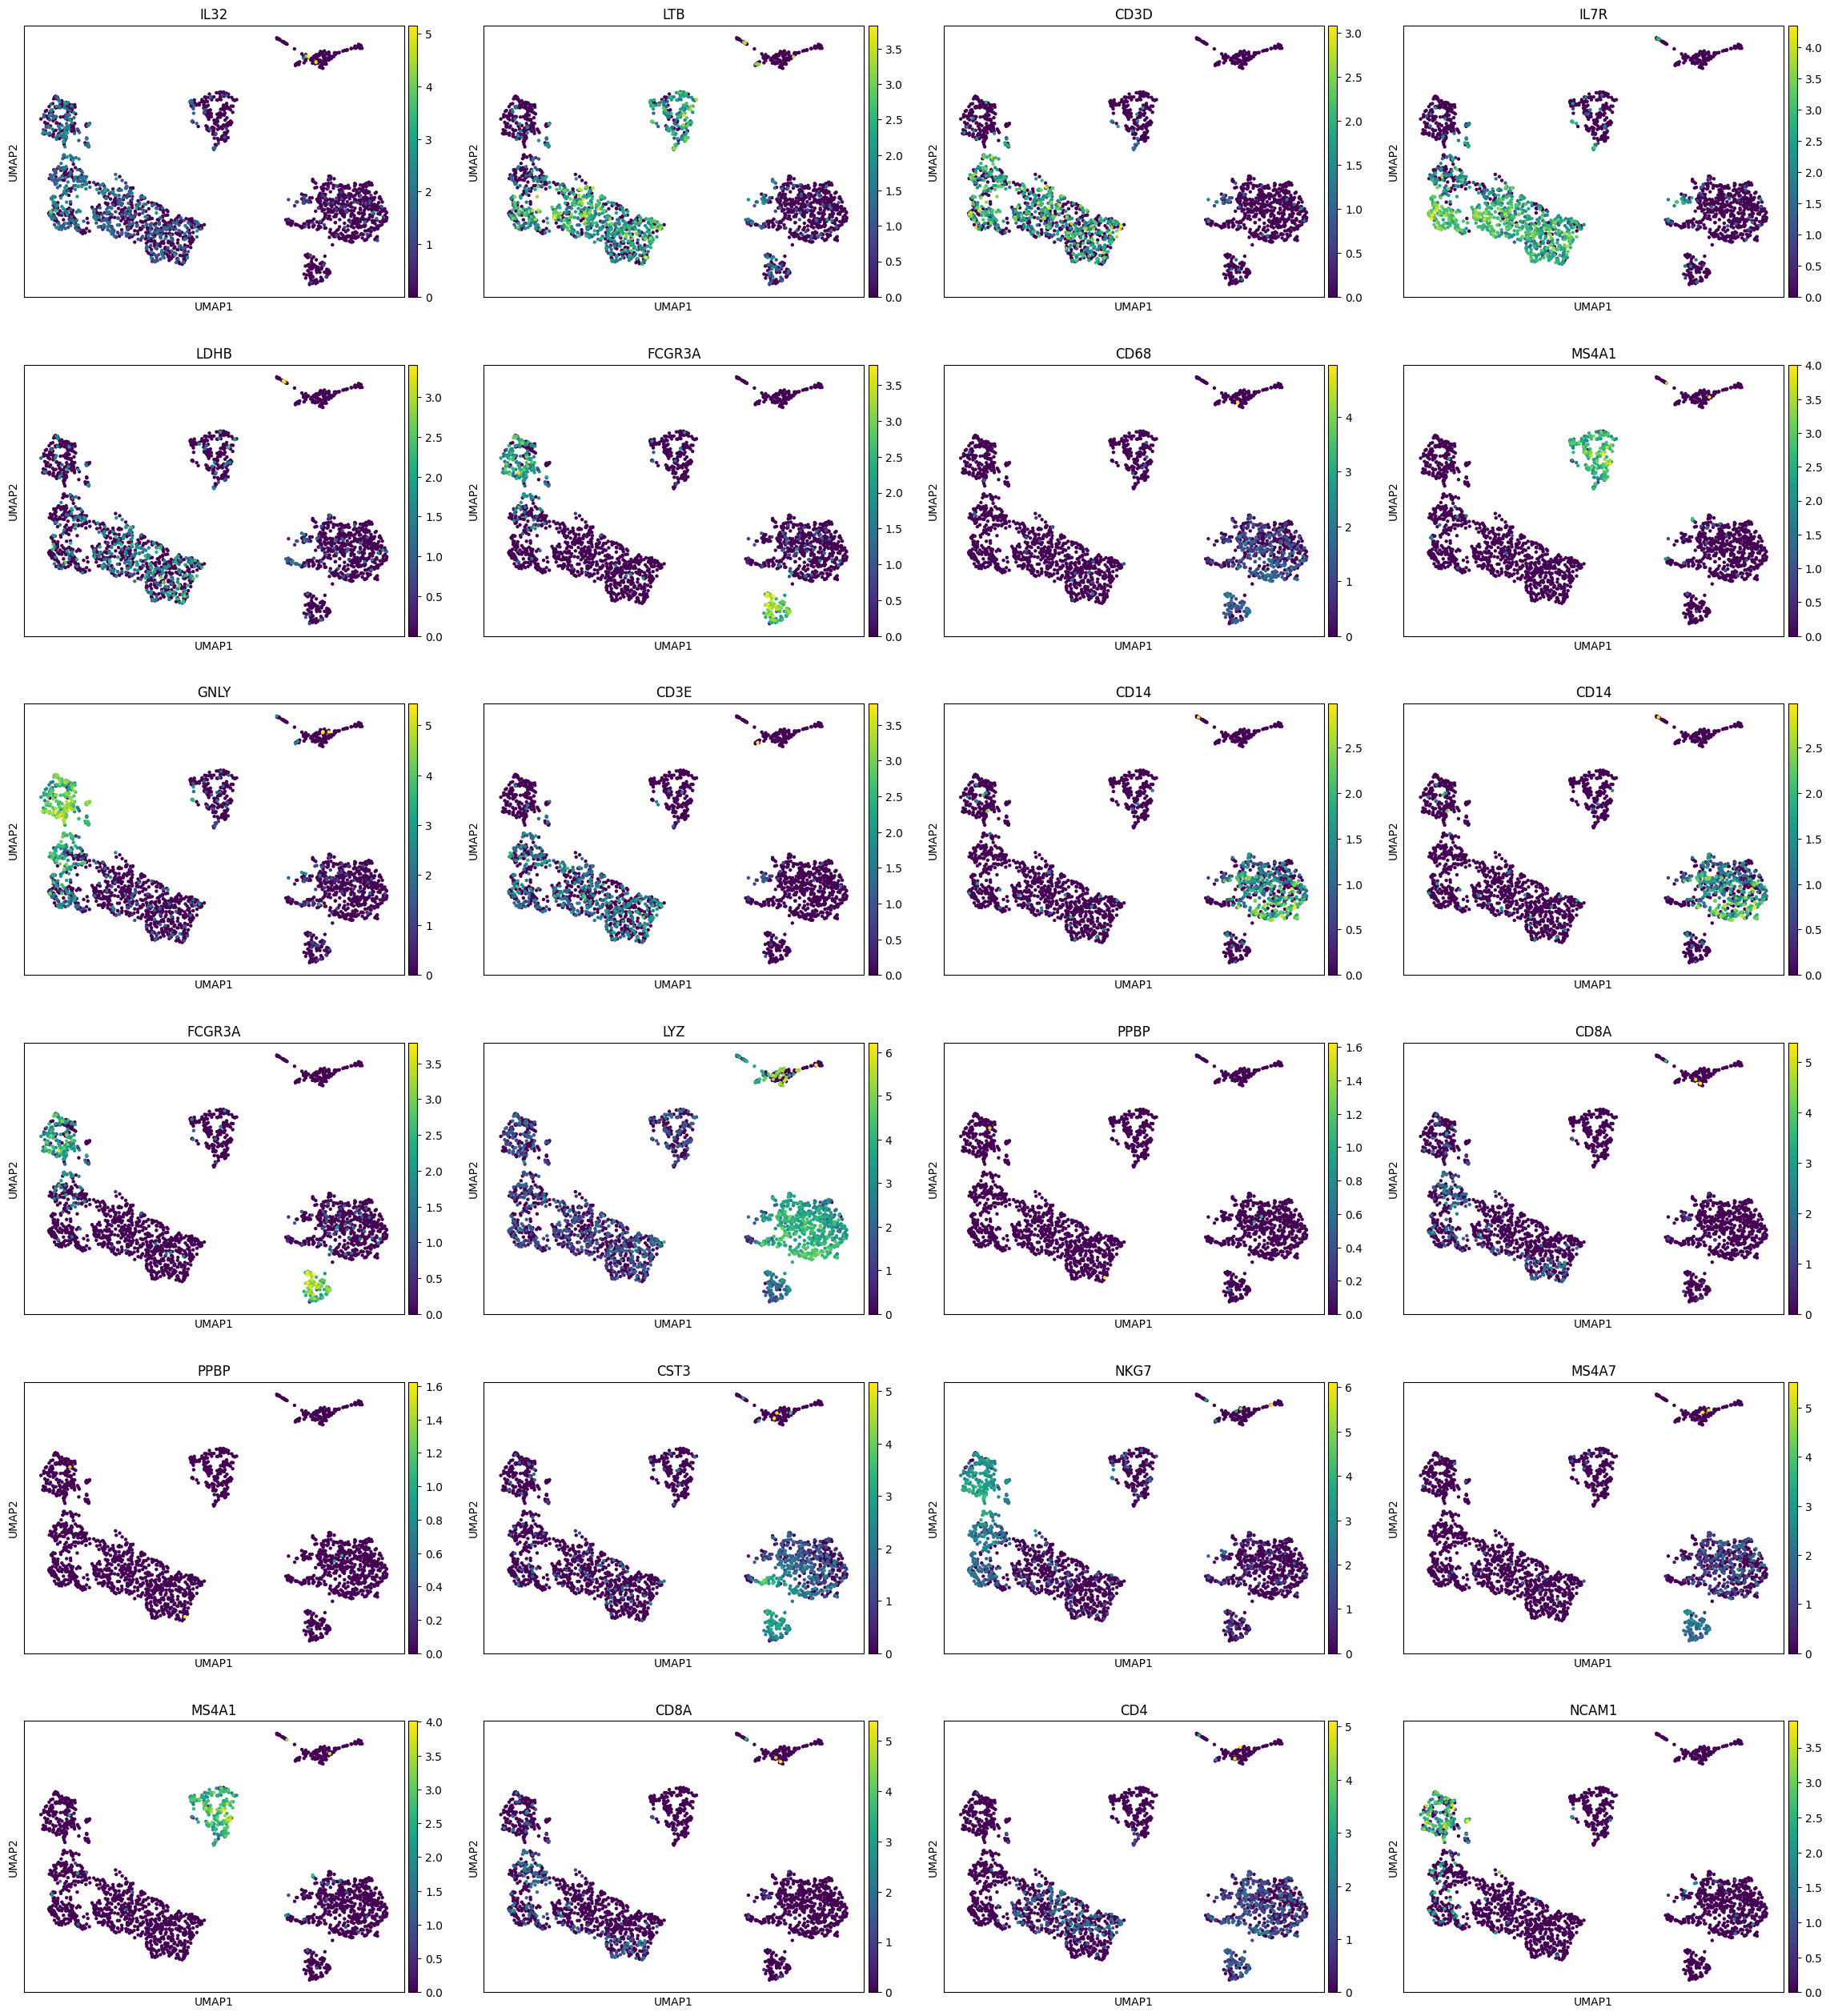

In [ ]:

canonical_markers_avail = [g for g in canonical_markers if g in h5_rna.var['gene_name'].values ]


# with plt.rc_context({'figure.figsize': (5, 5)}):
sc.pl.umap(h5_rna, color=canonical_markers_avail, wspace=0.1, ncols=4, size=40, gene_symbols='gene_name', layer='log1p_counts')

In [ ]:
sc.pl.umap(h5_rna, color=['SELL', 'IL7R', 'ITGAM'], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD127 protein : gene IL7R (T cells subtype)
# CD62L protein : gene SELL (T cells subtype)
# CD11B protein: ITGAM gene: T cells do not express ITGAM (myloid)

In [ ]:
sc.pl.umap(h5_rna, color=['CD3D', 'IL7R', 'CD8A', 'CD8B',  'NKG7', 'GNLY', 'FGFBP2', 'FCGR3A', 'FCER1G'], size=40 , gene_symbols='gene_name', layer='log1p_counts')

In [ ]:
sc.pl.umap(h5_rna, color=[ 'ITGAX',   'CD14','FCGR3A' ], size=40 , gene_symbols='gene_name', layer='log1p_counts')
# CD11c protein: gene ITGAX -- DC 
# CD16 protein: gene FCGR3A -- NC monocytes

#### gamma-delta T cells 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'TRDC',   'TRGC1','TRDV2', 'TRGV9'], size=40 , ncols=2, gene_symbols='gene_name', layer='log1p_counts') #

### pDCs and C14+ monocytes

In [ ]:
sc.pl.umap(h5_rna, color=[ 'CD14', 'IRF7', 'TLR9', 'TCF4', 'CLEC4C' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

####  MAIT/NK-T cells 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'KLRG1',   'NCR3','KLRB1'], size=40 ,gene_symbols='gene_name', layer='log1p_counts') #

#### 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'NCAM1',   'TBX21','IFNG', 'NKG7', 'XCL2', 'NCR1' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

#### Mono 

In [ ]:
sc.pl.umap(h5_rna, color=[ 'CD14',   'HLA-DRA', 'TNF', 'IL1B' ], size=40 ,ncols=3 ,gene_symbols='gene_name', layer='log1p_counts') #

In [ ]:
# cell-type idendification by Juliana

cluster_average_df = pd.DataFrame(index=h5_rna.var['gene_name'])

for c in h5_rna.obs['leiden_RNA_scVI'].unique():
    a = h5_rna[h5_rna.obs['leiden_RNA_scVI'] == c, :].layers['log1p_counts'].mean(axis=0)
    cluster_average_df[c] = np.asarray(a).flatten()
    
cluster_average_df.to_csv('HiJuliana_check_pbmc_rna_cluster_average_normalized_expression.csv')

cluster_average_df.head()

## Cell-type annotation from Julianaa

## Save average gene expression per cluster for Juliana to annotate cell-types

In [52]:
RNA_cell_clusters = h5_rna.obs['leiden_RNA_scVI'].unique()

cluster_gene_df = pd.DataFrame(index=h5_rna.var['gene_name'])

for c in RNA_cell_clusters:
    a = h5_rna[h5_rna.obs['leiden_RNA_scVI'] == c, :].layers['counts'].mean(axis=0)
    cluster_gene_df[c] = np.asarray(a).flatten()
    
save_file = os.path.join(entropy_dir, 'HiJuliana_check_pbmc_rna_cluster_average_raw_counts_UpdatedEntropyNormalization.csv')
cluster_gene_df.to_csv(save_file)

### Provicve clsuter to cell-type map

In [16]:
# Juliana's cell type annotation
# Juliana's cell type annotation
RNAcluster_celltype_map = {
'0': 'CD14+ Mo',
'1': 'CD4+CD8+ naive T cells',
'2': 'Tregs',
'3': 'B cells',
'4': 'ILC/NK cells',
'5': 'MAIT/NK T cells',
'6': 'gammaSignma T cells',
'7': 'Unknown',
'8': 'CD16+Mo',
'9': 'pDCs',
'10': 'Plasma cells (noisy)'
}
h5_rna.obs['celltype'] = h5_rna.obs['leiden_RNA_scVI'].map(RNAcluster_celltype_map)

## do NOT !!! delete 
## do NOT !!! delete 
## do NOT !!! delete 


# ## Save each cell-type's barcode 
# rna_cell_type_subdir = os.path.join(entropy_dir,  '_rna_cell_types')
# os.makedirs(rna_cell_type_subdir, exist_ok=True)

# #
# for cluster in h5_rna.obs['leiden_RNA_scVI'].unique():
#     write_file = 'RNAcluster_' + str(cluster) + '_df.csv' 
#     write_file_path = os.path.join(rna_cell_type_subdir, write_file)
#     h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == cluster, :].to_csv(write_file_path, index=False)
    
# # write cell-type mapping file
# celltype_map_file = os.path.join(rna_cell_type_subdir, 'RNAcluster_celltype_map.tsv')
# with open(celltype_map_file, 'w') as f:
#     for k, v in RNAcluster_celltype_map.items():
#         f.write(f"{k}\t{v}\n")

### plot to see cell-type fraction of reads in peaks (FRIP) for standard peak set and entropy peak set

In [17]:
if 'standard_peak_FRIP' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['standard_peak_FRIP'], inplace=True)
if 'entropy_peak_FRIP' in h5_rna.obs.columns:
    h5_rna.obs.drop(columns=['entropy_peak_FRIP'], inplace=True)
    
h5_rna.obs = h5_rna.obs.merge(standard_peak_frip[['frag_overlap_peaks%']].rename(columns={'frag_overlap_peaks%': 'standard_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')

h5_rna.obs = h5_rna.obs.merge(entropy_peak_frip[['frag_overlap_entropy_peaks%']].rename(columns={'frag_overlap_entropy_peaks%': 'entropy_peak_FRIP'}),\
    left_on='atac_bc', right_index=True, how='left')

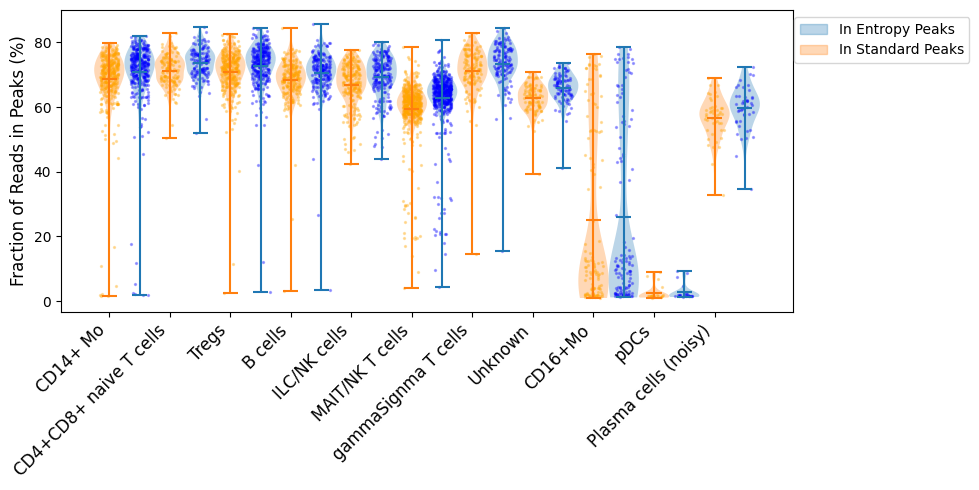

In [18]:
# color_maps = {'0': 'blue', '1': 'orange', '2': 'green', '3': 'red', '4': 'purple',
#               '5': 'brown', '6': 'pink', '7': 'gray', '8': 'olive', '9': 'cyan', '10': 'magenta'}
x_positions = range(11)
widths=0.5
labels = []

def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    
fig, ax = plt.subplots( figsize=(10, 5))

# Violin plots
standard_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'standard_peak_FRIP'] for c in h5_rna.obs['leiden_RNA_scVI'].unique()]
entropy_peak_data = [h5_rna.obs.loc[h5_rna.obs['leiden_RNA_scVI'] == c, 'entropy_peak_FRIP'] for c in h5_rna.obs['leiden_RNA_scVI'].unique()]
add_label(ax.violinplot( entropy_peak_data, 
              positions=[x + widths for x in x_positions], widths=widths, vert=True, 
              showmeans=True,), 'In Entropy Peaks',)

add_label(ax.violinplot( standard_peak_data, 
              positions=x_positions, widths=widths, vert=True, 
              showmeans=True), 'In Standard Peaks',)


# Overlay jittered scatter points
np.random.seed(999)
def add_jittered_points(ax, data_group, position, jitter_width=0.15, color='blue'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.3, s=2) # s controls point size

for i, group_data in enumerate(standard_peak_data):
    add_jittered_points(ax, group_data, x_positions[i], color='orange')
for i, group_data in enumerate(entropy_peak_data):
    add_jittered_points(ax, group_data, [x + widths for x in x_positions][i], color='blue')



ax.set_xticks(x_positions)
ax.set_xticklabels([RNAcluster_celltype_map[str(c)] for c in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylabel('Fraction of Reads in Peaks (%)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(1.25, 1), ncol=1)

plt.tight_layout()


In [19]:
h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['Entropy', 'Entropy_open_region']], left_on='atac_bc', right_index=True, how='left')
h5_rna.obs['Entropy_log'] = np.log10(h5_rna.obs['Entropy'])

## Plot to see consistency between atac space and rna space 

In [20]:
if 'clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy', axis=1, inplace=True)
if 'clusters_peakvi_highres_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_highres_entropy', axis=1, inplace=True)

if 'clusters_peakvi_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_standard', axis=1, inplace=True)
if 'clusters_peakvi_highres_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_highres_standard', axis=1, inplace=True)
    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_entropy', 'clusters_peakvi_highres_entropy']], left_on='atac_bc', right_index=True, how='left')
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_standard', 'clusters_peakvi_highres_standard']], left_on='atac_bc', right_index=True, how='left')

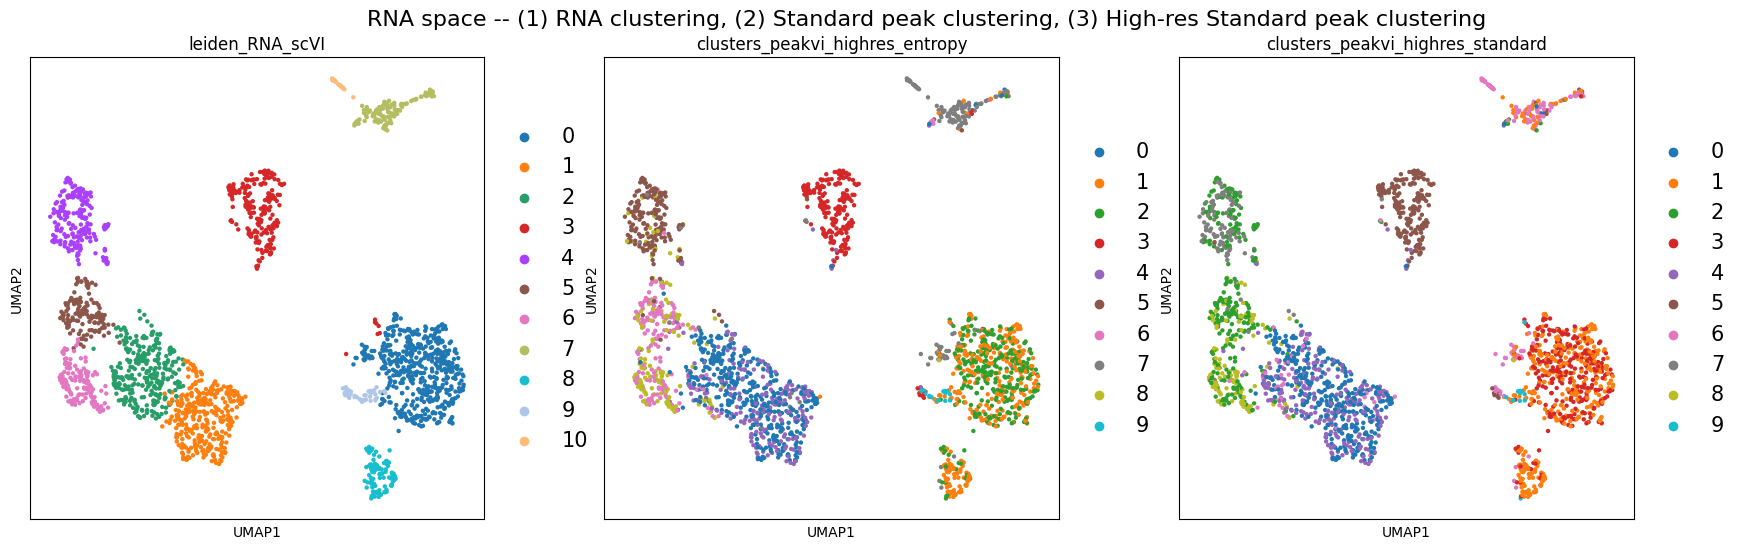

In [ ]:
with plt.rc_context({'figure.figsize': (6, 6)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI', 'clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard'], wspace=0.15, ncols=3, size=40, legend_fontsize=15, show=False)
    plt.suptitle('RNA space -- (1) RNA clustering, (2) Standard peak clustering, (3) High-res Standard peak clustering', fontsize=16)
    
    plt.show()

### match cluster by majority 

In [22]:
relate_labels = peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_standard', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)

relate_labels = relate_labels.to_numpy()

ordered_col, remained_col = order_m(relate_labels)




# # Now manually map the best matching clusters
cluster_map = {str(i):str(j) for i, j in zip(list(range(relate_labels.shape[1])), ordered_col+remained_col)}
cluster_map
#entropy_peak.obs['reorder_clusters_peakvi_entropy'] = entropy_peak.obs['clusters_peakvi_entropy'].map(cluster_map)

entropy_peak.obs['reorder_clusters_peakvi_entropy'] = entropy_peak.obs['clusters_peakvi_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)
# sc.pl.umap(entropy_peak, color='reorder_clusters_peakvi_entropy')


relate_labels[:, ordered_col + remained_col]

/tmp/ipykernel_52891/3238120664.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels = peak_df.join(entropy_peak_df['clusters_peakvi_entropy']).groupby(['clusters_peakvi_standard', 'clusters_peakvi_entropy']).size().unstack(fill_value=0)


array([[469,   0,   4, 162,   0],
       [165, 224,   4, 116,   0],
       [  2,   0, 420,   0,   1],
       [  0,   0, 348,   0,   0],
       [  1,   0,   0,   0, 210]])

In [23]:
if 'clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_entropy', axis=1, inplace=True)
if 'reorder_clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('reorder_clusters_peakvi_entropy', axis=1, inplace=True)

if 'clusters_peakvi_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_standard', axis=1, inplace=True)
    



h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['clusters_peakvi_entropy', 'reorder_clusters_peakvi_entropy']], left_on='atac_bc', right_index=True, how='left')
h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_standard']], left_on='atac_bc', right_index=True, how='left')

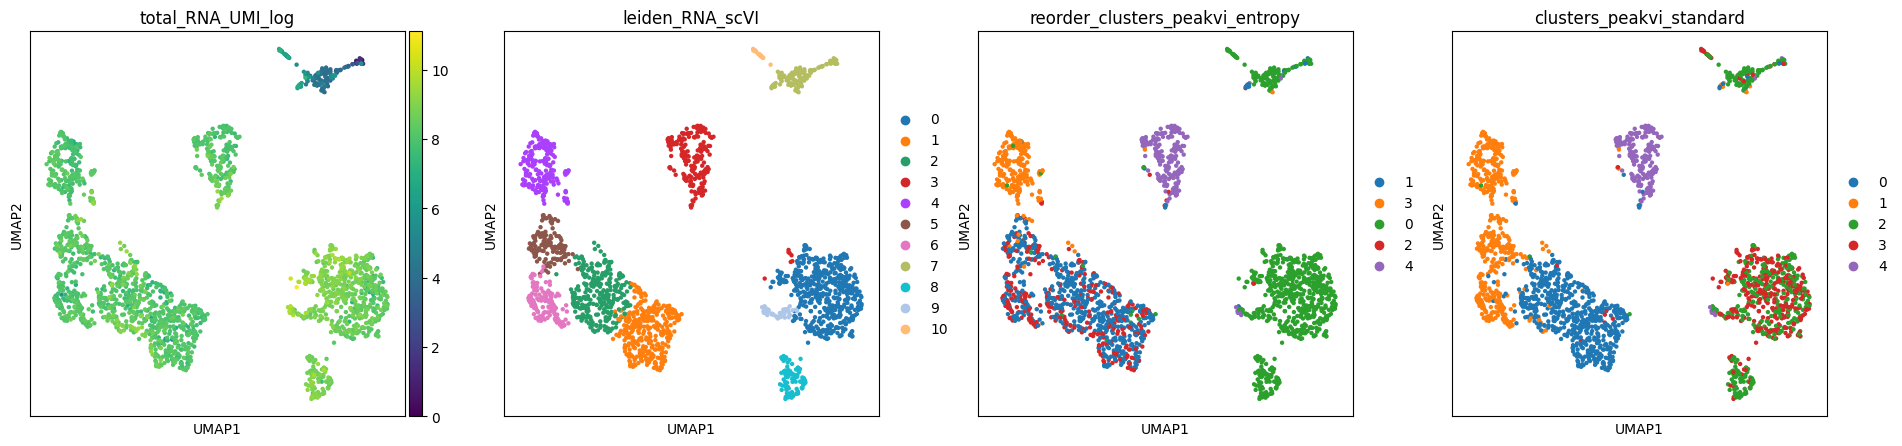

In [24]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna, color=['total_RNA_UMI_log', 'leiden_RNA_scVI', 'reorder_clusters_peakvi_entropy', 'clusters_peakvi_standard'], wspace=0.15, ncols=4, size=40)

### On finer resolution

In [27]:
relate_labels2 = peak_df.join(entropy_peak_df['clusters_peakvi_highres_entropy']).groupby(['clusters_peakvi_highres_standard', 'clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)

relate_labels2 = relate_labels2.to_numpy()
ordered_col, remained_col = order_m(relate_labels2)

# # Now manually map the best matching clusters
entropy_peak.obs['reorder_clusters_peakvi_highres_entropy'] = entropy_peak.obs['clusters_peakvi_highres_entropy'].cat.reorder_categories([str(i) for i in ordered_col+remained_col], ordered=False)

/tmp/ipykernel_52891/3685768261.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  relate_labels2 = peak_df.join(entropy_peak_df['clusters_peakvi_highres_entropy']).groupby(['clusters_peakvi_highres_standard', 'clusters_peakvi_highres_entropy']).size().unstack(fill_value=0)


In [28]:
if 'reorder_clusters_peakvi_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('reorder_clusters_peakvi_entropy', axis=1, inplace=True)
if 'reorder_clusters_peakvi_highres_entropy' in h5_rna.obs.columns:
    h5_rna.obs.drop('reorder_clusters_peakvi_highres_entropy', axis=1, inplace=True)

if 'clusters_peakvi_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_standard', axis=1, inplace=True)
if 'clusters_peakvi_highres_standard' in h5_rna.obs.columns:
    h5_rna.obs.drop('clusters_peakvi_highres_standard', axis=1, inplace=True)

    

h5_rna.obs = h5_rna.obs.merge(entropy_peak.obs[['reorder_clusters_peakvi_entropy', 'reorder_clusters_peakvi_highres_entropy']], left_on='atac_bc', right_index=True, how='left')

h5_rna.obs = h5_rna.obs.merge(peak.obs[['clusters_peakvi_standard', 'clusters_peakvi_highres_standard']], left_on='atac_bc', right_index=True, how='left')

# with plt.rc_context({'figure.figsize': (5, 5)}):
#     sc.pl.umap(h5_rna, color=['total_RNA_UMI_log', 'leiden_RNA_scVI', 'reorder_clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard'], wspace=0.14, ncols=2, size=40)

/tmp/ipykernel_52891/1280846987.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = sns.clustermap(h5_rna.obs.groupby(['reorder_clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard']).size().unstack(fill_value=0),  \


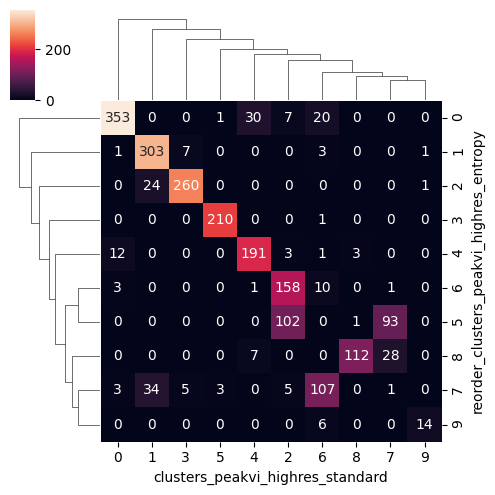

In [29]:
g = sns.clustermap(h5_rna.obs.groupby(['reorder_clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard']).size().unstack(fill_value=0),  \
    figsize=(5, 5), metric='euclidean', method='average', annot=True, fmt=".0f", annot_kws={"size": 10})
plt.show()

In [30]:
(h5_rna.obs['MT%'] < 20).sum(), h5_rna.shape[0]

(2062, 2126)

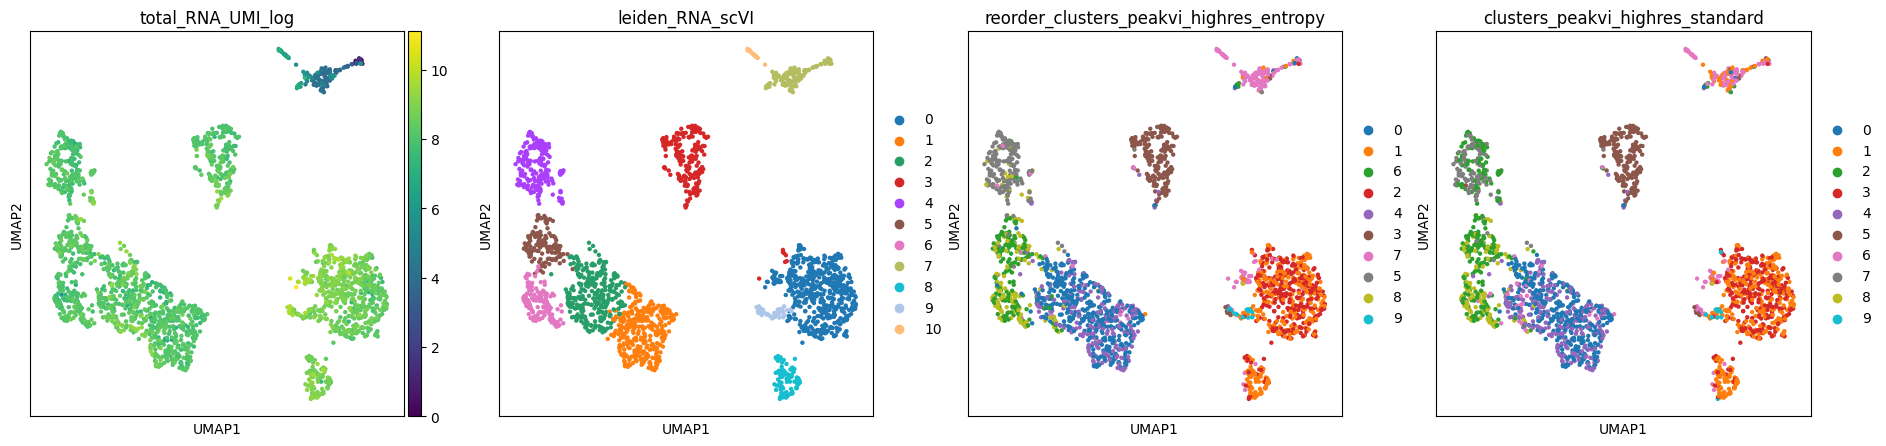

In [33]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    #sc.pl.umap(h5_rna[h5_rna.obs['MT%'] < 20], color=['total_RNA_UMI_log', 'leiden_RNA_scVI', 'reorder_clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard'], wspace=0.14, ncols=2, size=40)
    sc.pl.umap(h5_rna, color=['total_RNA_UMI_log', 'leiden_RNA_scVI', 'reorder_clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard'], wspace=0.14, ncols=4, size=40)

#### Name section

In [35]:
h5_rna.obs.groupby(['celltype']).size(), 44/482

/tmp/ipykernel_52891/4112103800.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h5_rna.obs.groupby(['celltype']).size(), 44/482


(celltype
 CD14+ Mo                  504
 CD4+CD8+ naive T cells    334
 Tregs                     301
 B cells                   215
 ILC/NK cells              208
 MAIT/NK T cells           138
 gammaSignma T cells       135
 Unknown                   124
 CD16+Mo                    98
 pDCs                       46
 Plasma cells (noisy)       23
 dtype: int64,
 0.0912863070539419)

/tmp/ipykernel_52891/2701972909.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = sns.clustermap(h5_rna.obs.groupby(['celltype', 'reorder_clusters_peakvi_highres_entropy']).size().unstack(fill_value=0),  \


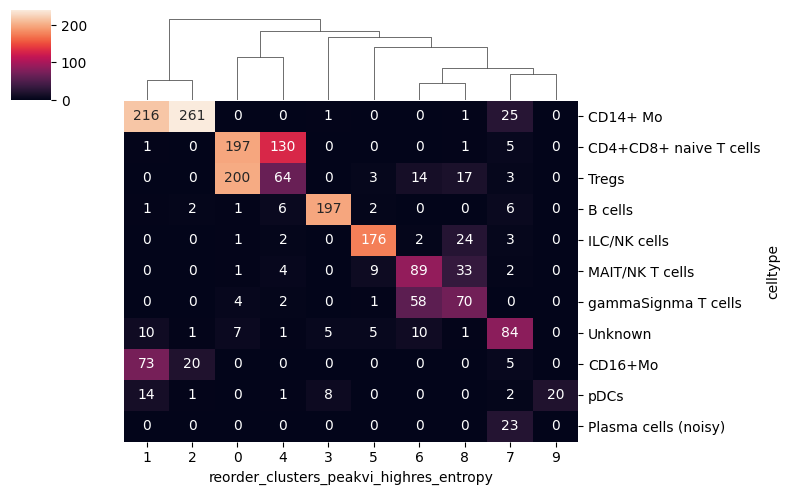

In [36]:


g = sns.clustermap(h5_rna.obs.groupby(['celltype', 'reorder_clusters_peakvi_highres_entropy']).size().unstack(fill_value=0),  \
    figsize=(8, 5), metric='euclidean', annot=True, fmt=".0f", annot_kws={"size": 10},  vmin = 0, vmax = 240,
    row_cluster=False, col_cluster=True)

# g.ax_heatmap.set_xlabel('Standard peak cluster', fontsize=12)
# g.ax_heatmap.set_ylabel('Entropy peak cluster', fontsize=12)
plt.show()

In [59]:
sns.clustermap(h5_rna.obs.groupby(['celltype', 'clusters_peakvi_highres_standard']).size().unstack(fill_value=0),  \
    figsize=(8, 5), metric='euclidean', annot=True, fmt=".0f", annot_kws={"size": 10},  vmin = 0, vmax = 240,
    row_cluster=False, col_cluster=True)

plt.show()

/tmp/ipykernel_52891/167216521.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.clustermap(h5_rna.obs.groupby(['celltype', 'clusters_peakvi_highres_standard']).size().unstack(fill_value=0),  \


In [60]:

with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna, color=['leiden_RNA_scVI',  'reorder_clusters_peakvi_highres_entropy', 'clusters_peakvi_highres_standard'], wspace=0.14, ncols=3, size=40)

#### Doublet score

In [54]:
import doubletdetection
clf = doubletdetection.BoostClassifier(
    n_iters=10, 
    clustering_algorithm="louvain", 
    standard_scaling=True,
    pseudocount=0.1,
    n_jobs=-1,
)
doublets = clf.fit(h5_rna.layers['counts'].toarray()).predict(p_thresh=1e-16, voter_thresh=0.5)
doublet_score = clf.doublet_score()

h5_rna.obs["RNA_doublet_score"] = doublet_score
h5_rna.obs["RNA_predicted_doublet"] = ['doublets' if x else 'singlets' for x in doublets]

100%|██████████| 10/10 [00:08<00:00,  1.12it/s]


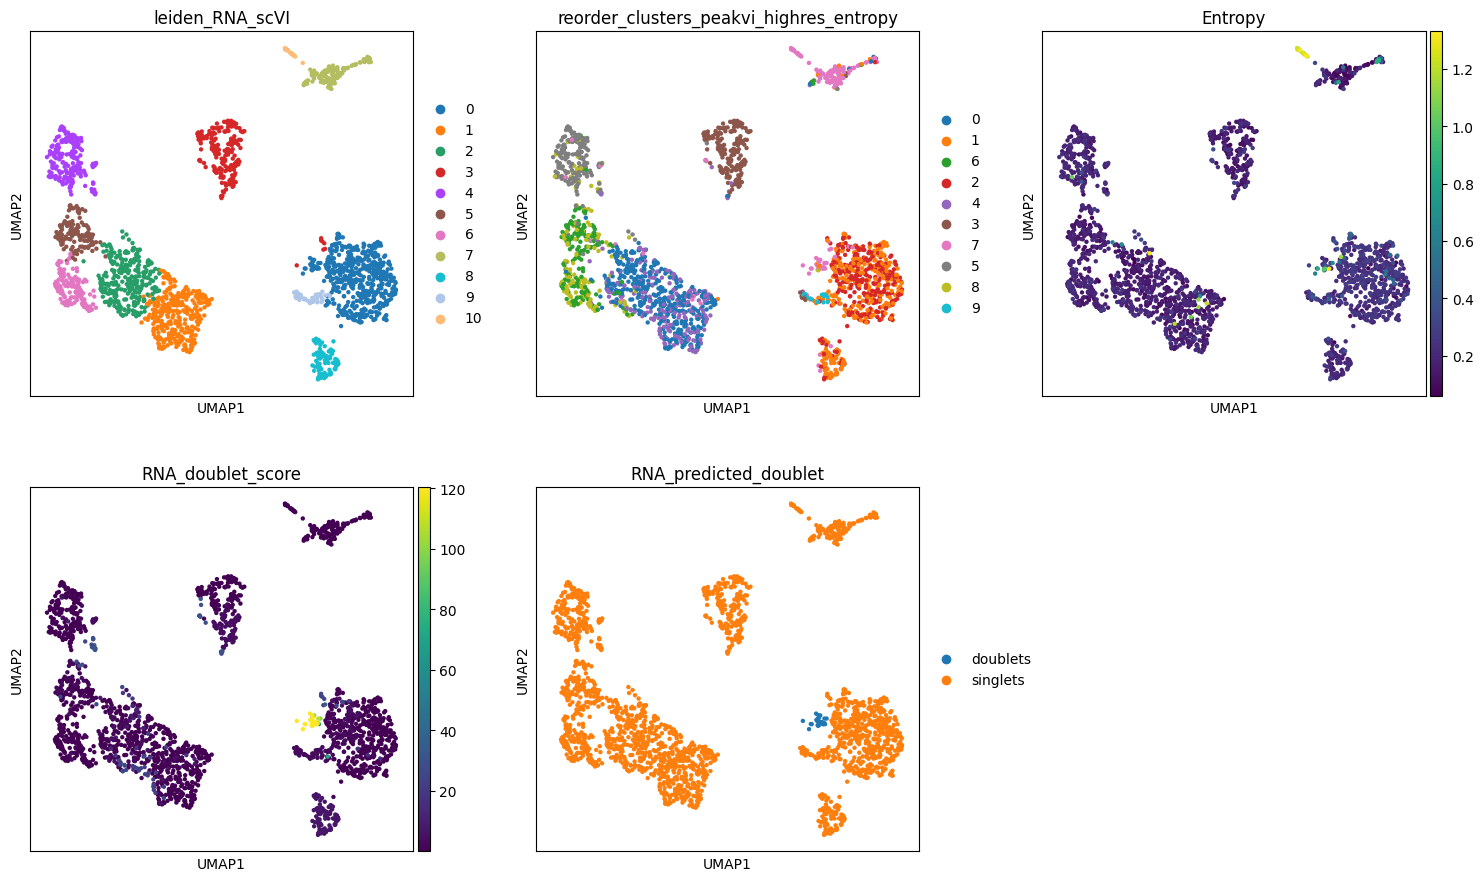

In [65]:
with plt.rc_context({'figure.figsize': (5, 5)}):
    sc.pl.umap(h5_rna, color=["leiden_RNA_scVI", "reorder_clusters_peakvi_highres_entropy", "Entropy", "RNA_doublet_score", "RNA_predicted_doublet"], size=40, ncols=3, wspace=0.2)
    

Text(0, 0.5, 'Entropy Score')

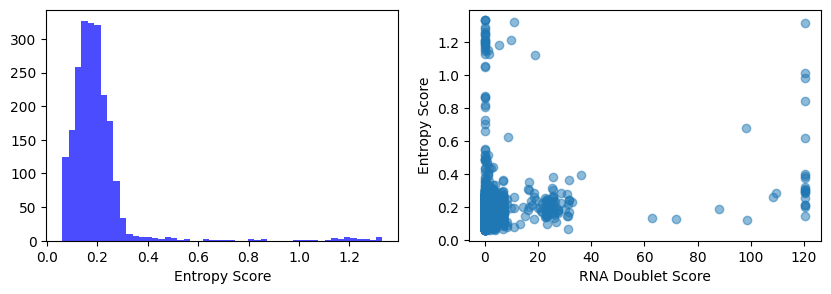

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
_ = ax[0].hist(h5_rna.obs['Entropy'], bins=50, color='blue', alpha=0.7)
ax[0].set_xlabel('Entropy Score')

ax[1].scatter(h5_rna.obs['RNA_doublet_score'], h5_rna.obs['Entropy'],  alpha=0.5)
ax[1].set_xlabel('RNA Doublet Score')
ax[1].set_ylabel('Entropy Score')

Text(0.5, 0, 'Entropy value (log)')

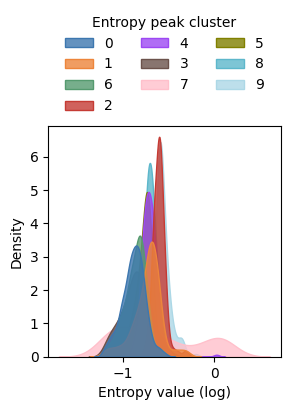

In [66]:
color_order = {'0': '#3d77af', '1': '#ed853b', '2': '#559a6f', '3': '#c53b34', '4': '#9d48f3',
             '5': '#6b524b', '6': 'pink', '7': 'olive', '8': '#5db7cb', '9': 'lightblue', 
                '10': '#f6a04d', '11': '#8fd18b', '12': 'lightcoral'}#, '13': 'lime'}
entropy_peak_cluster_order = h5_rna.obs['reorder_clusters_peakvi_highres_entropy'].cat.categories.tolist()
color_map = {k: color_order[str(i)] for i, k in enumerate(entropy_peak_cluster_order)}

fig, ax = plt.subplots(figsize=(3, 3))
kde = sns.kdeplot(data=h5_rna.obs, x='Entropy_log', hue='reorder_clusters_peakvi_highres_entropy', 
                  palette=color_map,
                  fill=True, 
                  ax=ax, alpha=0.8, common_norm=False)
sns.move_legend(
    kde, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title='Entropy peak cluster', frameon=False
)

ax.set_xlabel('Entropy value (log)')


In [67]:
h5_rna.obs['reorder_clusters_peakvi_highres_entropy'].cat.categories

Index(['0', '1', '6', '2', '4', '3', '7', '5', '8', '9'], dtype='object')

### closer look at Entropy cluster 7

In [68]:
entropy_c12_h5 = h5_rna[h5_rna.obs['clusters_peakvi_highres_entropy'] == '7', :].copy()

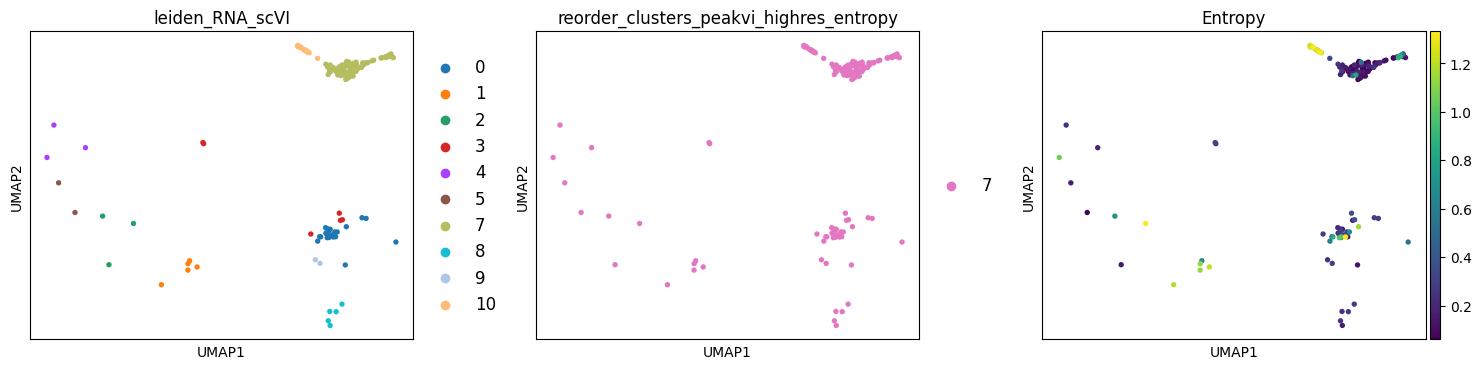

In [69]:
with plt.rc_context({'figure.figsize': (5, 4)}):
    sc.pl.umap(entropy_c12_h5, color=['leiden_RNA_scVI', 'reorder_clusters_peakvi_highres_entropy', 'Entropy'], wspace=0.2, ncols=3, size=60, legend_fontsize=12, show=False)
    

# On ATAC space

## Umap on ATAC space

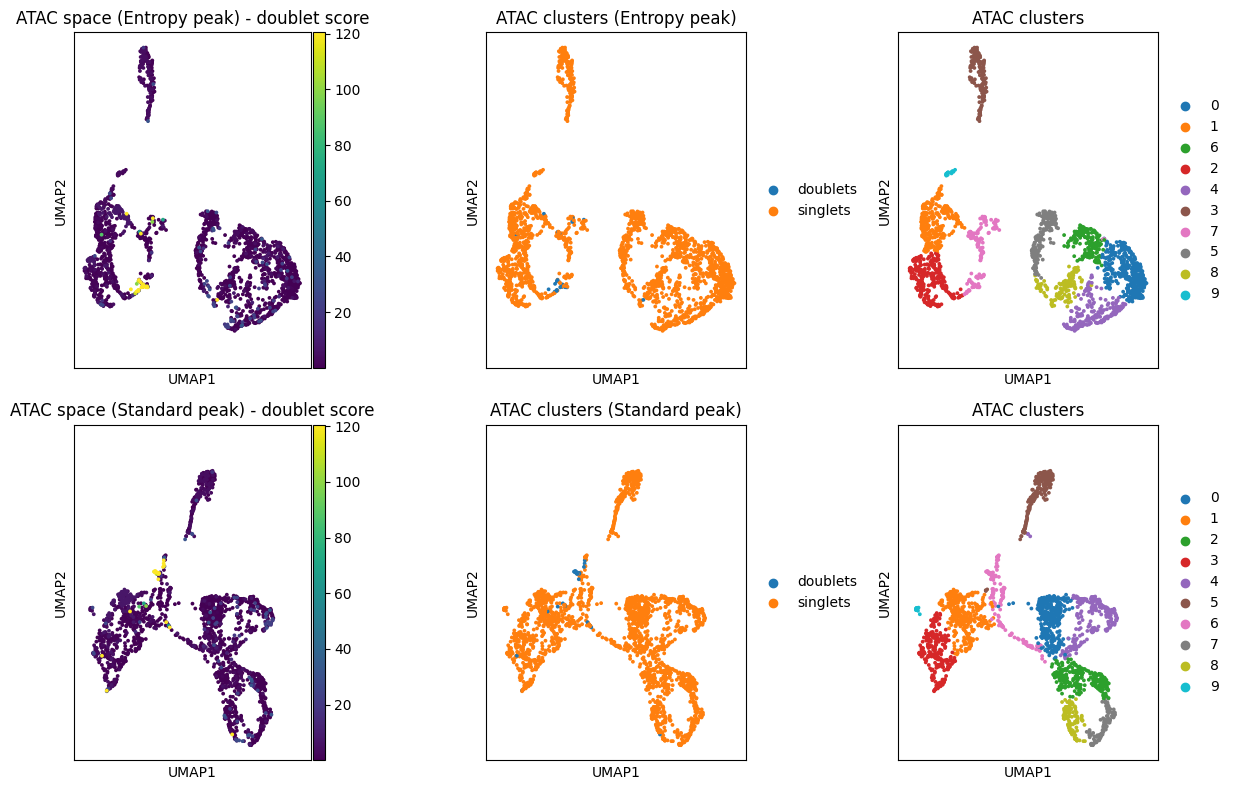

In [76]:
if 'RNA_doublet_score' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('RNA_doublet_score', axis=1, inplace=True)
if 'RNA_predicted_doublet' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('RNA_predicted_doublet', axis=1, inplace=True)
    
if 'RNA_doublet_score' in peak.obs.columns:
    peak.obs.drop('RNA_doublet_score', axis=1, inplace=True)
if 'RNA_predicted_doublet' in peak.obs.columns:
    peak.obs.drop('RNA_predicted_doublet', axis=1, inplace=True)
    
entropy_peak.obs = entropy_peak.obs.merge(h5_rna.obs[['RNA_doublet_score', 'RNA_predicted_doublet']], left_on='rna_barcodes', right_index=True, how='left')
peak.obs = peak.obs.merge(h5_rna.obs[['RNA_doublet_score', 'RNA_predicted_doublet']], left_on='rna_barcodes', right_index=True, how='left')




fig, ax = plt.subplots(2, 3, figsize=(12,8), sharex=True, sharey=True)
ax = ax.flatten()
sc.pl.umap(entropy_peak, color=['RNA_doublet_score'], title='ATAC space (Entropy peak) - doublet score', size=30, ax=ax[0], show=False)
sc.pl.umap(entropy_peak, color=['RNA_predicted_doublet'], title='ATAC clusters (Entropy peak)', size=30, ax=ax[1], show=False)
sc.pl.umap(entropy_peak, color=['reorder_clusters_peakvi_highres_entropy'], title='ATAC clusters', size=30, ax=ax[2], show=False)


sc.pl.umap(peak, color=['RNA_doublet_score'], title='ATAC space (Standard peak) - doublet score', size=30, ax=ax[3], show=False)
sc.pl.umap(peak, color=['RNA_predicted_doublet'], title='ATAC clusters (Standard peak)', size=30, ax=ax[4], show=False)
sc.pl.umap(peak, color=['clusters_peakvi_highres_standard'], title='ATAC clusters', size=30, ax=ax[5], show=False)

fig.tight_layout()

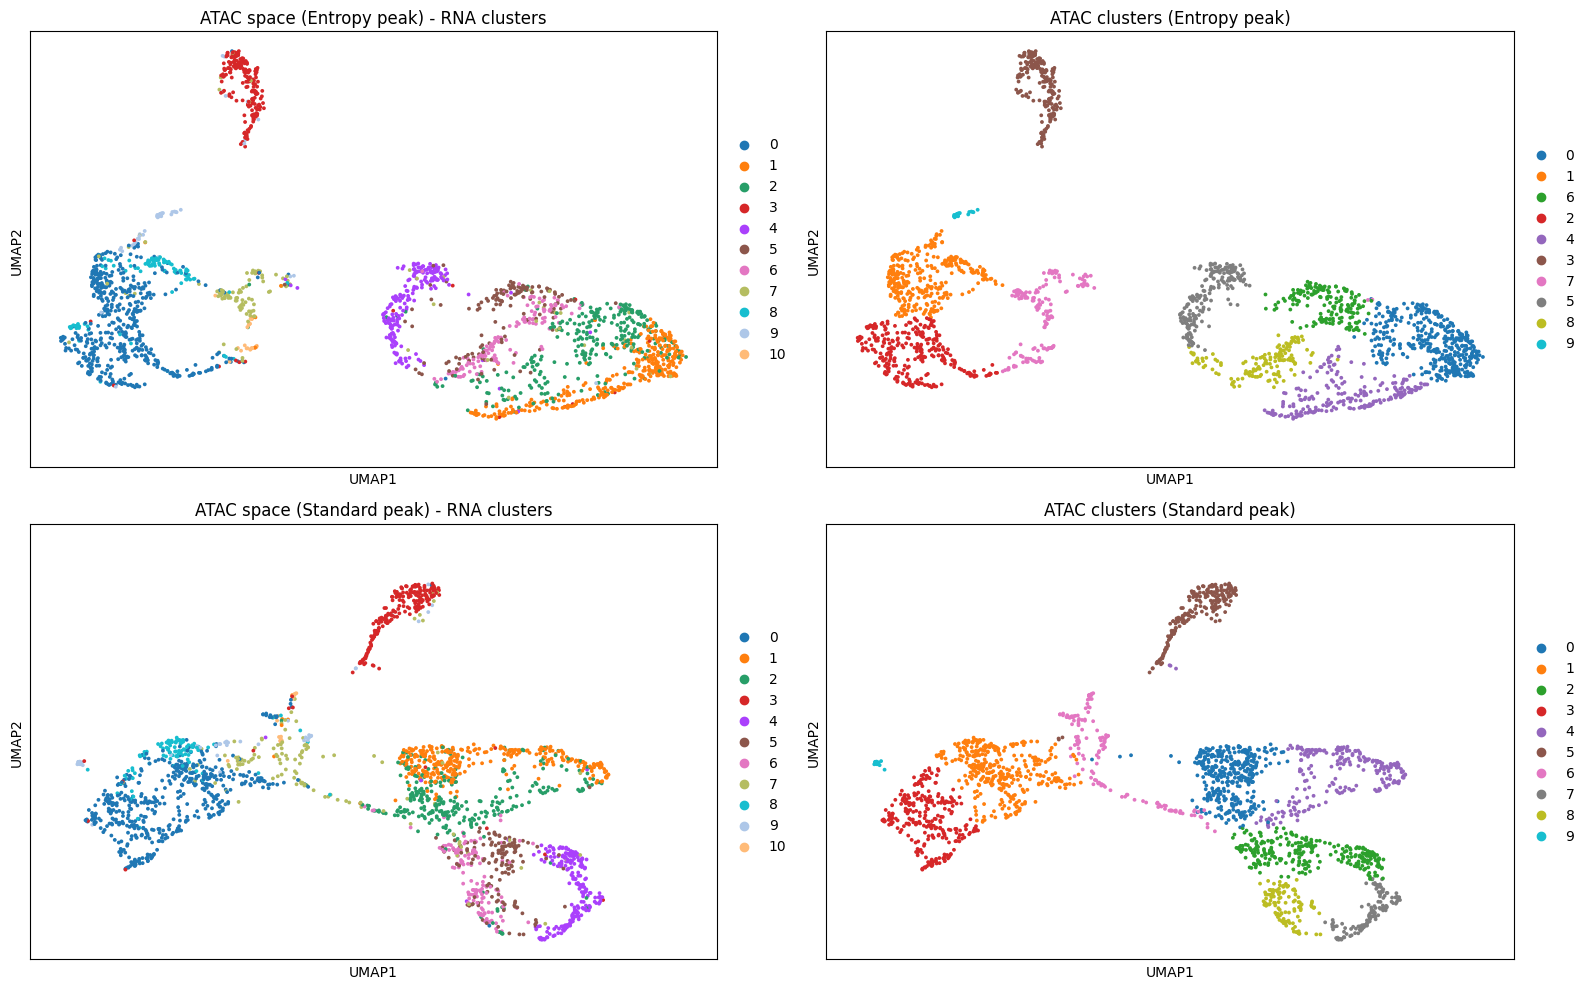

In [70]:
if 'leiden_RNA_scVI' in entropy_peak.obs.columns:
    entropy_peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
if 'leiden_RNA_scVI' in peak.obs.columns:
    peak.obs.drop('leiden_RNA_scVI', axis=1, inplace=True)
    
entropy_peak.obs = entropy_peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')
peak.obs = peak.obs.merge(h5_rna.obs[['leiden_RNA_scVI']], left_on='rna_barcodes', right_index=True, how='left')



fig, ax = plt.subplots(2, 2, figsize=(16,10), sharex=True, sharey=True)
ax = ax.flatten()
sc.pl.umap(entropy_peak, color=['leiden_RNA_scVI'], title='ATAC space (Entropy peak) - RNA clusters', size=30, ax=ax[0], show=False)
sc.pl.umap(entropy_peak, color=['reorder_clusters_peakvi_highres_entropy'], title='ATAC clusters (Entropy peak)', size=30, ax=ax[1], show=False)


sc.pl.umap(peak, color=['leiden_RNA_scVI'], title='ATAC space (Standard peak) - RNA clusters', size=30, ax=ax[2], show=False)
sc.pl.umap(peak, color=['clusters_peakvi_highres_standard'], title='ATAC clusters (Standard peak)', size=30, ax=ax[3], show=False)


fig.tight_layout()

## DARs analysis to see top peaks 

### Get Differentially accessible regions on Standard peak set, and Entropy peak set respectively

In [62]:
standard_DARs = {}
for cluster in peak.obs['clusters_peakvi_highres_standard'].unique():
    print(f" DARs on StandardPeak-higherres-cluster {cluster}")
    standard_DARs[cluster] = standard_peak_model.differential_accessibility(
        groupby="clusters_peakvi_highres_standard", group1=cluster,  two_sided=True
    )

 DARs on StandardPeak-higherres-cluster 2
DE...: 100%|██████████| 1/1 [00:28<00:00, 28.59s/it]
 DARs on StandardPeak-higherres-cluster 5
DE...: 100%|██████████| 1/1 [00:12<00:00, 12.56s/it]
 DARs on StandardPeak-higherres-cluster 1
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.25s/it]
 DARs on StandardPeak-higherres-cluster 6
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.28s/it]
 DARs on StandardPeak-higherres-cluster 0
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.21s/it]
 DARs on StandardPeak-higherres-cluster 3
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.22s/it]
 DARs on StandardPeak-higherres-cluster 8
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.24s/it]
 DARs on StandardPeak-higherres-cluster 4
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.20s/it]
 DARs on StandardPeak-higherres-cluster 7
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.15s/it]
 DARs on StandardPeak-higherres-cluster 9
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.22s/it]


In [63]:
entropy_DARs = {}
for cluster in entropy_peak.obs['reorder_clusters_peakvi_highres_entropy'].unique():
    print(f" DARs on EntropyPeak-highres-cluster {cluster}")
    entropy_DARs[cluster] = entropy_peak_model.differential_accessibility(
        groupby="reorder_clusters_peakvi_highres_entropy", group1=cluster,  two_sided=True
    )

 DARs on EntropyPeak-highres-cluster 6
DE...: 100%|██████████| 1/1 [00:05<00:00,  5.46s/it]
 DARs on EntropyPeak-highres-cluster 3
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.74s/it]
 DARs on EntropyPeak-highres-cluster 1
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.74s/it]
 DARs on EntropyPeak-highres-cluster 0
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.75s/it]
 DARs on EntropyPeak-highres-cluster 7
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.74s/it]
 DARs on EntropyPeak-highres-cluster 5
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.72s/it]
 DARs on EntropyPeak-highres-cluster 2
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.81s/it]
 DARs on EntropyPeak-highres-cluster 8
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.79s/it]
 DARs on EntropyPeak-highres-cluster 4
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.83s/it]
 DARs on EntropyPeak-highres-cluster 9
DE...: 100%|██████████| 1/1 [00:04<00:00,  4.89s/it]


In [64]:
## Have to manually change effect-size sign 
# It's supposed to be positive for up-regulated DARs in the cluster according to their tutorial [est_prob1 - est_prob2], see: https://docs.scvi-tools.org/en/1.0.0/tutorials/notebooks/PeakVI.html#:~:text=effect_size,-is%20the%20effect
# However in their code:    "effect_size": result.scale2 - result.scale1, see: https://github.com/scverse/scvi-tools/blob/908476d4d8dab57b0462d4d3147b3ac42c42eadd/src/scvi/model/_peakvi.py#L514 .
# Can also see in our results: effect_size := est_prob1 - est_prob2 (but sign is reversed)


standard_DARs['0'].head()

,prob_da,is_da_fdr,bayes_factor,effect_size,emp_effect,est_prob1,est_prob2,emp_prob1,emp_prob2
19813,0.9870,True,4.329720,0.401152,0.201889,0.300818,0.701969,0.104839,0.306727
23441,0.9854,True,4.212025,0.512742,0.244326,0.210389,0.723131,0.080645,0.324971
11099,0.9836,True,4.093937,0.445735,0.266555,0.408713,0.854449,0.118280,0.384835
30271,0.9836,True,4.093937,0.405675,0.231456,0.316930,0.722605,0.094086,0.325542
20939,0.9830,True,4.057395,0.397128,0.225583,0.438301,0.835430,0.147849,0.373432


In [81]:
## manually change effect-size sign 

for cluster in entropy_DARs.keys():
    entropy_DARs[cluster]['effect_size_correct_sign'] = -entropy_DARs[cluster]['effect_size']
    
for cluster in standard_DARs.keys():
    standard_DARs[cluster]['effect_size_correct_sign'] = -standard_DARs[cluster]['effect_size']

### Vis DARs

## Load peak info -- (rediscovered, newly-discovred, or lost labels)

In [65]:
peak_comparison_dir = os.path.join(entropy_dir, 'peaks_comparison')
lost_peaks_anno_file = os.path.join(peak_comparison_dir, 'lost_peaks.bed')
newly_discovered_peaks_anno_file = os.path.join(peak_comparison_dir, 'newly_discovered_peaks.bed')
recovered_peaks_anno_file = os.path.join(peak_comparison_dir, 'recovered_peaks.bed')

In [66]:
lost_peaks_anno = pd.read_csv(lost_peaks_anno_file, header=None, sep='\t')  # Correspond to Standard peaks called using all the reads
newly_discovered_peaks_anno = pd.read_csv(newly_discovered_peaks_anno_file, header=None, sep='\t') # Correspond to Entropy peaks called using only the reads retained after entropy filtering
recovered_peaks_anno = pd.read_csv(recovered_peaks_anno_file, header=None, sep='\t') # In both peak sets [first half of the columns are from Standard peaks, second half from Entropy peaks]

In [67]:
lost_peaks_anno.head()

,0,1,2,3,4,5,6,7,8,9
0,chr1,2663175,2663930,peak_134,342,.,257.992554,3.048749,-1,63
1,chr1,2664230,2665587,peak_135,371,.,503.672852,2.914509,-1,679
2,chr1,2671720,2672357,peak_136,436,.,277.447876,3.144313,-1,144
3,chr1,2748299,2748725,peak_138,501,.,213.434113,3.235945,-1,181
4,chr1,2756527,2757065,peak_139,509,.,273.738647,3.205816,-1,66


In [68]:
newly_discovered_peaks_anno.head()

,0,1,2,3,4,5,6,7,8,9
0,chr1,976091,976507,peak_37,718,.,298.713104,3.889583,-1,104
1,chr1,1079635,1080360,peak_48,378,.,273.852325,2.925739,-1,400
2,chr1,1099017,1099710,peak_49,560,.,388.165863,3.187065,-1,364
3,chr1,1216758,1217371,peak_59,352,.,215.721832,3.016338,-1,410
4,chr1,1440975,1441155,peak_72,1000,.,238.236420,3.859016,-1,82


In [69]:
recovered_peaks_anno.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,chr1,817208,817719,peak_33,1000,.,885.841309,5.154950,-1,201,...,817095,817735,peak_29,1000,.,1076.479126,5.626846,-1,314,511
1,chr1,826857,828146,peak_34,1000,.,3416.727539,8.459686,-1,731,...,826855,828152,peak_30,1000,.,3954.863281,9.110286,-1,734,1289
2,chr1,869760,870205,peak_35,1000,.,824.793945,5.856312,-1,168,...,869759,870207,peak_31,1000,.,1011.600586,6.493548,-1,169,445
3,chr1,904403,905173,peak_36,1000,.,1179.364014,6.310306,-1,326,...,904394,905173,peak_32,1000,.,1400.058105,6.841429,-1,335,770
4,chr1,906808,907046,peak_37,1000,.,289.819641,3.906523,-1,82,...,906808,907056,peak_33,1000,.,368.891113,4.307378,-1,127,238


In [70]:
entropy_peak.var.head()

,peak
0,chr1:817095-817735
1,chr1:826855-828152
2,chr1:869759-870207
3,chr1:904394-905173
4,chr1:906808-907056


In [71]:
lost_peaks_anno.index = lost_peaks_anno.apply(lambda x: f"{x[0]}:{x[1]}-{x[2]}", axis=1)
lost_peaks_anno.index.name = 'Standard_peak'

newly_discovered_peaks_anno.index = newly_discovered_peaks_anno.apply(lambda x: f"{x[0]}:{x[1]}-{x[2]}", axis=1)
newly_discovered_peaks_anno.index.name = 'Entropy_peak'

recovered_peaks_anno['Standard_peak'] = recovered_peaks_anno.apply(lambda x: f"{x[0]}:{x[1]}-{x[2]}", axis=1)
recovered_peaks_anno['Entropy_peak'] = recovered_peaks_anno.apply(lambda x: f"{x[10]}:{x[11]}-{x[12]}", axis=1)

In [72]:
newly_discovered_peaks_anno.head()

,0,1,2,3,4,5,6,7,8,9
Entropy_peak,,,,,,,,,,
chr1:976091-976507,chr1,976091,976507,peak_37,718,.,298.713104,3.889583,-1,104
chr1:1079635-1080360,chr1,1079635,1080360,peak_48,378,.,273.852325,2.925739,-1,400
chr1:1099017-1099710,chr1,1099017,1099710,peak_49,560,.,388.165863,3.187065,-1,364
chr1:1216758-1217371,chr1,1216758,1217371,peak_59,352,.,215.721832,3.016338,-1,410
chr1:1440975-1441155,chr1,1440975,1441155,peak_72,1000,.,238.236420,3.859016,-1,82


In [73]:
print( f'Entropy peaks total: {entropy_peak.shape[-1]}, \n \
    newly discovered: {entropy_peak.var["peak"].isin(newly_discovered_peaks_anno.index).sum()}, \n \
    lost: {entropy_peak.var["peak"].isin(lost_peaks_anno.index).sum()}, \n \
    recovered: {entropy_peak.var["peak"].isin(recovered_peaks_anno["Entropy_peak"]).sum()}' )

Entropy peaks total: 36730, 
     newly discovered: 6141, 
     lost: 0, 
     recovered: 30589


In [74]:
print( f'Peaks total: {peak.shape[-1]}, \n \
    newly discovered: {peak.var["peak"].isin(newly_discovered_peaks_anno.index).sum()}, \n \
    lost: {peak.var["peak"].isin(lost_peaks_anno.index).sum()}, \n \
    recovered: {peak.var["peak"].isin(recovered_peaks_anno["Standard_peak"]).sum()}' )

Peaks total: 31116, 
     newly discovered: 0, 
     lost: 35, 
     recovered: 31081


In [75]:
# percentaeg of lost peaks, newly discovered peaks (denominator is total peaks in the standard peak set)
# lost peaks: unique peaks in standard peak set but not in entropy peak set
# newly discovered peaks: unique peaks in entropy peak set but not in standard peak set
1 - 35 / 31116, 6141 / 31116

(0.998875176757938, 0.19735827227150018)

## Check Standard peak clustering vs Entropy peak clustering DARs type [recovered, lost, or newly-discovered]

In [76]:

for key in entropy_DARs.keys():

    id = entropy_DARs[key].index.values 
    entropy_DARs[key]['Entropy_peak'] = entropy_peak.var.loc[id, 'peak']
    entropy_DARs[key]['lost_peak'] = entropy_DARs[key]['Entropy_peak'].isin(lost_peaks_anno.index)
    entropy_DARs[key]['newly_discovered_peak'] = entropy_DARs[key]['Entropy_peak'].isin(newly_discovered_peaks_anno.index)
    entropy_DARs[key]['recovered_peak'] = entropy_DARs[key]['Entropy_peak'].isin(recovered_peaks_anno["Entropy_peak"])


for key in standard_DARs.keys():
    
    id = standard_DARs[key].index.values
    standard_DARs[key]['Standard_peak'] = peak.var.loc[id, 'peak']
    standard_DARs[key]['lost_peak'] = standard_DARs[key]['Standard_peak'].isin(lost_peaks_anno.index)
    standard_DARs[key]['newly_discovered_peak'] = standard_DARs[key]['Standard_peak'].isin(newly_discovered_peaks_anno.index)
    standard_DARs[key]['recovered_peak'] = standard_DARs[key]['Standard_peak'].isin(recovered_peaks_anno["Standard_peak"])

In [79]:
h5_rna.obs['clusters_peakvi_highres_standard'].cat.categories , h5_rna.obs['reorder_clusters_peakvi_highres_entropy'].cat.categories

(Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype='object'),
 Index(['0', '1', '6', '2', '4', '3', '7', '5', '8', '9'], dtype='object'))

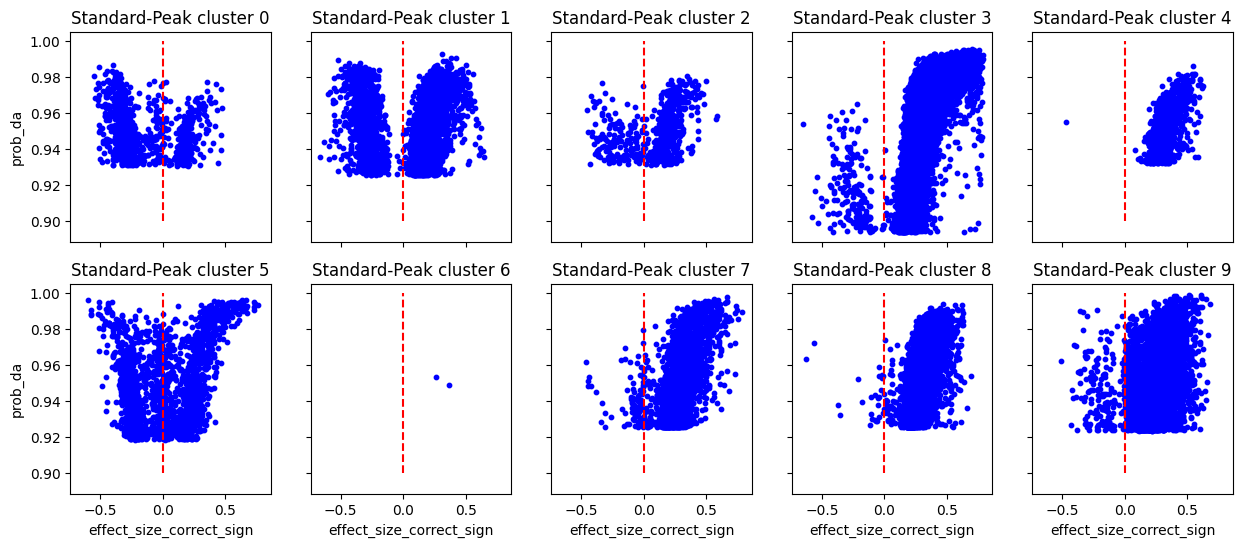

In [87]:

fig, axes = plt.subplots(2, 5, figsize=(15,6), sharex=True, sharey=True)
axes = axes.flatten()
# for i, cluster in enumerate(standard_DARs.keys()):
# To plot in corresponding cluster order
for i, cluster in enumerate(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']):
    ax = axes[i]
    standard_DARs[cluster].loc[(standard_DARs[cluster]['is_da_fdr']) & (standard_DARs[cluster]['recovered_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'Standard-Peak cluster {cluster}', s = 10, c='blue' ) 
    standard_DARs[cluster].loc[(standard_DARs[cluster]['is_da_fdr']) & (standard_DARs[cluster]['lost_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', ax=ax, title=f'Standard-Peak cluster {cluster}', s = 10, c='grey' )   
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
plt.show()

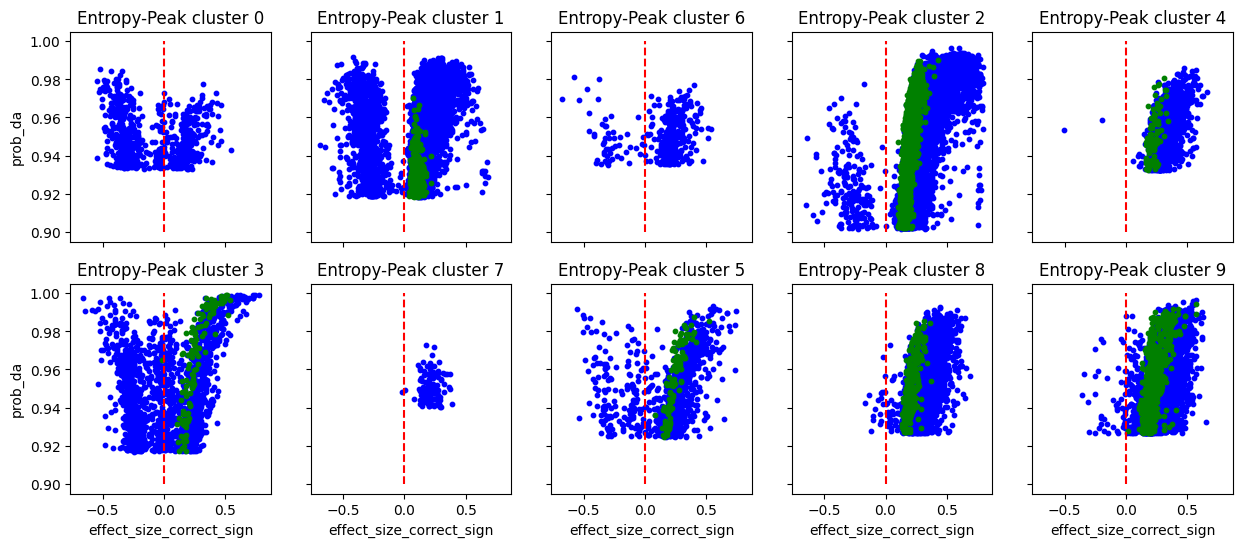

In [88]:
fig, axes = plt.subplots(2, 5, figsize=(15,6), sharex=True, sharey=True)
axes = axes.flatten()
# for i, cluster in enumerate(entropy_DARs.keys()):
# To plot in corresponding cluster order
for i, cluster in enumerate(['0', '1', '6', '2', '4', '3', '7', '5', '8', '9']):
    ax = axes[i]
    entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) & (entropy_DARs[cluster]['recovered_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', \
        ax=ax, title=f'Entropy-Peak cluster {cluster}', s=10, c='blue' )     
    entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) & (entropy_DARs[cluster]['newly_discovered_peak'])].plot.scatter(x='effect_size_correct_sign', y='prob_da', \
        ax=ax, title=f'Entropy-Peak cluster {cluster}', s=10 , c='green') 
    ax.vlines(x=0, color='red', ymin=0.9, ymax=1, linestyle='--')
plt.show()

In [89]:
def create_DARs_stats(DARs_stats_dict, index_name):
    DAR_stats_df = pd.DataFrame(columns=['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_lost_peaks', 'DARs_in_newly_discovered_peaks'])
    
    for key in DARs_stats_dict.keys():
        NDAR_in_recovered = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'recovered_peak'].sum()
        NDAR_in_lost = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'lost_peak'].sum()
        NDAR_in_newly_discovered = DARs_stats_dict[key].loc[DARs_stats_dict[key]['is_da_fdr'], 'newly_discovered_peak'].sum()
        
        DAR_stats_df.loc[key, 'total_DARs'] = DARs_stats_dict[key]['is_da_fdr'].sum()
        DAR_stats_df.loc[key, 'DARs_in_recovered_peaks'] = NDAR_in_recovered
        DAR_stats_df.loc[key, 'DARs_in_lost_peaks'] = NDAR_in_lost
        DAR_stats_df.loc[key, 'DARs_in_newly_discovered_peaks'] = NDAR_in_newly_discovered
        
    DAR_stats_df.index.name = index_name
    
    return DAR_stats_df

In [90]:
entropy_DARs_stats = create_DARs_stats(entropy_DARs, index_name='Entropy_peak_cluster')
standard_DARs_stats = create_DARs_stats(standard_DARs, index_name='Standard_peak_cluster')


standard_DARs_stats_perc = standard_DARs_stats.div(standard_DARs_stats['total_DARs'], axis=0) * 100
standard_DARs_stats_perc.columns = [col + '_perc' for col in standard_DARs_stats_perc.columns]
standard_DARs_stats_perc['total_DARs'] = standard_DARs_stats['total_DARs'] # add back total_DARs column for reference


entropy_DARs_stats_perc = entropy_DARs_stats.div(entropy_DARs_stats['total_DARs'], axis=0) * 100
entropy_DARs_stats_perc.columns = [col + '_perc' for col in entropy_DARs_stats_perc.columns]
entropy_DARs_stats_perc['total_DARs'] = entropy_DARs_stats['total_DARs'] # add back total_DARs column for reference

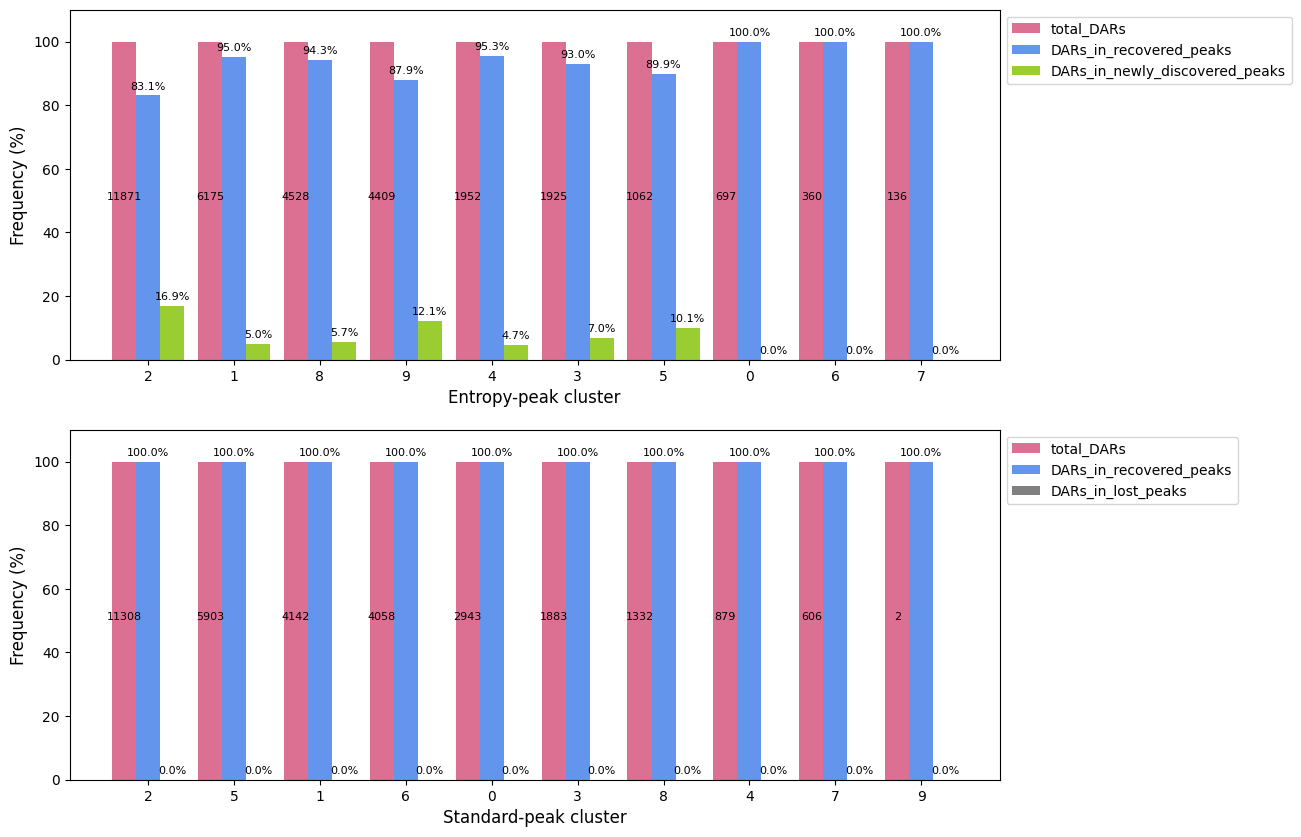

In [91]:

color_map = {'total_DARs': 'palevioletred', 'DARs_in_recovered_peaks': 'cornflowerblue', 'DARs_in_lost_peaks': 'grey', 'DARs_in_newly_discovered_peaks': 'yellowgreen'}


plot_order_by_total_DARs = standard_DARs_stats.sort_values(by='total_DARs', ascending=False).index.values 
standard_DARs_stats2 = standard_DARs_stats.loc[plot_order_by_total_DARs]
standard_DARs_stats_perc2 = standard_DARs_stats_perc.loc[plot_order_by_total_DARs]

plot_order_by_total_DARs = entropy_DARs_stats.sort_values(by='total_DARs', ascending=False).index.values
entropy_DARs_stats2 = entropy_DARs_stats.loc[plot_order_by_total_DARs]
entropy_DARs_stats_perc2 = entropy_DARs_stats_perc.loc[plot_order_by_total_DARs]



width = 0.28  # the width of the bars
fig, ax = plt.subplots(2, 1, figsize=(12,10))





# for attribute  in entropy_DARs_stats.columns:
x = np.arange(entropy_DARs_stats2.shape[0])  # the label locations
multiplier = 0
for attribute  in ['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_newly_discovered_peaks']:
    offset = width * multiplier
    rects = ax[0].bar(x + offset, entropy_DARs_stats_perc2[attribute+'_perc'], width, label=attribute, color=color_map[attribute])
    if attribute == 'total_DARs':
        value_labels = entropy_DARs_stats2[attribute].values
        value_pos = 'center'
        ax[0].bar_label(rects, labels=value_labels , padding=3, fontsize=8, label_type=value_pos) 
    else:
        value_labels = entropy_DARs_stats_perc2[attribute+'_perc']
        value_pos = 'edge'
        ax[0].bar_label(rects, labels=[f'{x:,.1f}%' for x in value_labels] , padding=3, fontsize=8, label_type=value_pos) 
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax[0].set_ylabel('Frequency (%)', fontsize=12)
# ax[0].set_title('Entropy-Peak cluster DARs statistics')    
ax[0].set_xlabel('Entropy-peak cluster', fontsize=12) 
ax[0].set_xticks(x + width, entropy_DARs_stats2.index)
ax[0].legend(loc='upper left', ncols=1, bbox_to_anchor=(1,1))
ax[0].set_ylim(0, 100* 1.1)
y_labels = ax[0].get_yticklabels()
y_labels[-1].set_visible(False)



x = np.arange(standard_DARs_stats2.shape[0])  # the label locations
multiplier = 0
for attribute  in ['total_DARs', 'DARs_in_recovered_peaks', 'DARs_in_lost_peaks']:
    offset = width * multiplier
    rects = ax[1].bar(x + offset, standard_DARs_stats_perc2[attribute+'_perc'], width, label=attribute, color=color_map[attribute])
    if attribute == 'total_DARs':
        value_labels = standard_DARs_stats2[attribute].values
        value_pos = 'center'
        ax[1].bar_label(rects, labels=value_labels , padding=3, fontsize=8, label_type=value_pos) 

    else:
        value_labels = standard_DARs_stats_perc2[attribute+'_perc']
        value_pos = 'edge'
        ax[1].bar_label(rects, labels=[f'{x:,.1f}%' for x in value_labels] , padding=3, fontsize=8, label_type=value_pos) 

    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax[1].set_ylabel('Frequency (%)', fontsize=12)
# ax[1].set_title('Standard-Peak cluster DARs statistics')
ax[1].set_xlabel('Standard-peak cluster', fontsize=12)
ax[1].set_xticks(x + width, standard_DARs_stats.index)
ax[1].legend(loc='upper left', ncols=1, bbox_to_anchor=(1,1))
ax[1].set_ylim(0, 100 * 1.1)
y_labels = ax[1].get_yticklabels()
y_labels[-1].set_visible(False)


plt.show()



In [93]:
concatenated_entropy_DARs = pd.DataFrame()
for i, cluster in enumerate(['0', '1', '6', '2', '4', '3', '7', '5', '8', '9']):
    df = entropy_DARs[cluster].loc[(entropy_DARs[cluster]['is_da_fdr']) & (entropy_DARs[cluster]['newly_discovered_peak'])].copy()
    df['cluster'] = 'entropy_c' + cluster
    concatenated_entropy_DARs = pd.concat([concatenated_entropy_DARs, df], axis=0)

    

In [94]:
# #peaks in newly discovered peaks that are DARs in any entropy cluster: 5241
concatenated_entropy_DARs['Entropy_peak'].value_counts(), concatenated_entropy_DARs.shape


(Entropy_peak
 chrX:11341338-11342219       4
 chr10:113273211-113273825    3
 chr12:212211-212676          3
 chr3:59386277-59386534       3
 chr20:47785151-47785810      3
                             ..
 chr7:22587442-22587670       1
 chr6:144637620-144637827     1
 chr3:31547464-31547695       1
 chr2:127176770-127177088     1
 chr2:74026070-74026489       1
 Name: count, Length: 2899, dtype: int64,
 (3439, 15))

# Check chronical marker gene's chromatin accessible region in peaks 

Ref: Mapping genetic effects on cell type-specific chromatin accessibility and annotating complex immune trait variants using single nucleus ATAC-seq in peripheral blood : Paola Benaglio et al. 

In [95]:
entropy_peakset_dir = os.path.join(entropy_dir, 'peaks_entropy_filtered')

entropy_peakset_file = os.path.join(entropy_peakset_dir, 'peaks.bed')


entropy_peaksset = pd.read_csv(entropy_peakset_file, header=None, sep='\t')

entropy_peaksset['peak'] = entropy_peaksset[0].astype(str) + ':' + entropy_peaksset[1].astype(str) + '-' + entropy_peaksset[2].astype(str)

In [96]:
if 'entropy_peak_name' in entropy_peak.var.columns:
    entropy_peak.var.drop('entropy_peak_name', axis=1, inplace=True)

entropy_peak.var = entropy_peak.var.merge(entropy_peaksset[[3, 'peak']], left_on='peak', right_on='peak', how='left')
entropy_peak.var.rename(columns={3: 'entropy_peak_name'}, inplace=True)

entropy_peak.var.head()


,peak,entropy_peak_name
0,chr1:817095-817735,peak_29
1,chr1:826855-828152,peak_30
2,chr1:869759-870207,peak_31
3,chr1:904394-905173,peak_32
4,chr1:906808-907056,peak_33


In [97]:

entropy_peak_plot = entropy_peak.copy()
entropy_peak_plot.var.set_index('entropy_peak_name', inplace=True)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [99]:
# NK-cells  
## NCR1  
# name: peak_19704
# location: chr19:54905933-54906212
# score: 835.0

# B cells
## MS4A1 
# name: peak_6326
# location: chr11:60455546-60455895
# score: 1000.0

# Activated CD8+ T cells
## IFNG
# name: peak_8656
# location: chr12:68159654-68160000
# score: 1000.0

# # T-cells 
## CD3D
# name: peak_7310
# location: chr11:118338531-118339381
# score: 1000.0
# name: peak_7311
# location: chr11:118344195-118344434
# score: 1000.0


# CD4+ T cells
## CD4
# name: peak_7743
# location: chr12:6789380-6789719
# score: 1000.0
# name: peak_7744
# location: chr12:6792633-6793231
# score: 1000.0

# T-reg CD4+ T cells
## FOXP3
# name: peak_37110
# location: chrX:49235357-49235915
# score: 940.0

# CD8+ T cells
## CD8A
# name: peak_20882
# location: chr2:86785468-86785833
# score: 1000.0
# name: peak_20883
# location: chr2:86786051-86786600
# score: 1000.0
# name: peak_20884
# location: chr2:86790583-86791587
# score: 644.0

# Mono
## TNF
# name: peak_21239
# location: chr2:112836678-112837043
# score: 1000.0
# Intermediate Mono
# name: peak_30585
# location: chr6:31575336-31575912
# score: 1000.0
## HLA-DRA
# name: peak_30637
# location: chr6:32439390-32440066
# score: 1000.0

# Classical Monocytes
## CD14
# name: peak_29379
# location: chr5:140631052-140631380
# score: 1000.0
# name: peak_29380
# location: chr5:140631995-140633887
# score: 748.0

# Dendritic Cells
## DNAI2
# name: peak_16318
# location: chr17:74280030-74280540
# score: 1000.0
# name: peak_16319
# location: chr17:74282729-74283423
# score: 905.0
# name: peak_16320
# location: chr17:74301243-74301427
# score: 1000.0

# with plt.rc_context({'figure.figsize': (5, 5)}):
#     sc.pl.umap(entropy_peak_plot, color=['clusters_peakvi_highres_entropy', 'leiden_RNA_scVI', \
#         'peak_19704', 'peak_6326', 'peak_8656', \
#             'peak_7310','peak_7311', 'peak_7743', 'peak_7744', \
#                 'peak_37110' , \
#                     'peak_20882', 'peak_20883', 'peak_20884', \
#                         'peak_21239' , \
#                             'peak_30585', 'peak_30637', \
#                                 'peak_29379', 'peak_29380', \
#                                     'peak_16318', 'peak_16319', 'peak_16320'], \
#         size=40 , ncols=3, layer=None) 